2025-03-19 12:13:24,819 - INFO - Loading spectral data...
2025-03-19 12:13:24,821 - INFO - Processing Lab data...
2025-03-19 12:13:24,822 - INFO - Normalizing data...
2025-03-19 12:13:25,239 - INFO - Training the model...
2025-03-19 12:13:25,246 - INFO - Epoch 1/1000 - Hybrid Loss: 1.0046571493148804
2025-03-19 12:13:25,248 - INFO - Epoch 2/1000 - Hybrid Loss: 0.5820130109786987
2025-03-19 12:13:25,250 - INFO - Epoch 3/1000 - Hybrid Loss: 0.2509833872318268
2025-03-19 12:13:25,252 - INFO - Epoch 4/1000 - Hybrid Loss: 0.14747655391693115
2025-03-19 12:13:25,254 - INFO - Epoch 5/1000 - Hybrid Loss: 0.08971193432807922
2025-03-19 12:13:25,255 - INFO - Epoch 6/1000 - Hybrid Loss: 0.06709965318441391
2025-03-19 12:13:25,257 - INFO - Epoch 7/1000 - Hybrid Loss: 0.0780324935913086
2025-03-19 12:13:25,259 - INFO - Epoch 8/1000 - Hybrid Loss: 0.03971441835165024
2025-03-19 12:13:25,261 - INFO - Epoch 9/1000 - Hybrid Loss: 0.044668324291706085
2025-03-19 12:13:25,263 - INFO - Epoch 10/1000 - Hyb

Mean ΔE2000 Error: 3.904463340198988
Max ΔE2000 Error: 14.061041738228083


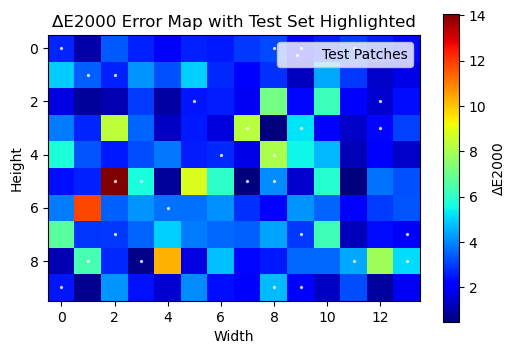

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_lab(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to Lab.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    lab = color.xyz2lab(xyz)
    return lab

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process Lab data
###########################################
logging.info('Processing Lab data...')
lab_input = process_lab(cube_data, wl_input, ill, CMFs)   
lab_ref   = process_lab(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data
###########################################
logging.info('Normalizing data...')
lab_input_2d = lab_input.reshape(-1, lab_input.shape[-1])
lab_ref_2d   = lab_ref.reshape(-1, lab_ref.shape[-1])

scaler_input = MinMaxScaler()
scaler_ref = MinMaxScaler()
X_norm = scaler_input.fit_transform(lab_input_2d)
Y_norm = scaler_ref.fit_transform(lab_ref_2d)

X_full = X_norm.reshape(lab_input.shape)
Y_full = Y_norm.reshape(lab_ref.shape)

###########################################
# 4. Prepare training data
###########################################
X_flat = X_full.reshape(-1, 3)
Y_flat = Y_full.reshape(-1, 3)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define a simple MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

model = SimpleMLP(input_size=3, hidden_size=128, output_size=3)
optimizer = optim.Adam(model.parameters(), lr=0.001)

###########################################
# 6. Hybrid Loss Function (Angular + MSE)
###########################################
class HybridLabLoss(nn.Module):
    def __init__(self, alpha=0.5, eps=1e-6):
        super(HybridLabLoss, self).__init__()
        self.alpha = alpha  
        self.eps = eps  
        self.mse_loss = nn.MSELoss()

    def forward(self, y_pred, y_true):
        y_pred_norm = torch.nn.functional.normalize(y_pred, p=2, dim=1, eps=self.eps)
        y_true_norm = torch.nn.functional.normalize(y_true, p=2, dim=1, eps=self.eps)
        cosine_similarity = torch.sum(y_pred_norm * y_true_norm, dim=1)
        cosine_similarity = torch.clamp(cosine_similarity, -1.0, 1.0)
        angular_loss = 1 - cosine_similarity  
        mse_loss = self.mse_loss(y_pred, y_true)
        total_loss = self.alpha * angular_loss.mean() + (1 - self.alpha) * mse_loss
        return total_loss

loss_function = HybridLabLoss(alpha=0.5)

###########################################
# 7. Training loop (using Hybrid Loss)
###########################################
epochs = 1000
batch_size = 32

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()
    
    logging.info(f'Epoch {epoch+1}/{epochs} - Hybrid Loss: {loss.item()}')

###########################################
# 8. Apply correction and evaluate
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_lab = scaler_ref.inverse_transform(corrected_flat)
corrected_lab_image = corrected_lab.reshape(lab_ref.shape)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab_image)

# Compute mean ΔE2000 error
# Flatten the error map for indexing
error_map_flat = error_map.reshape(-1)
# Extract only test-set errors using precomputed test_indices
test_error_values = error_map_flat[test_indices]
# Compute mean & max ΔE2000 error for the test set
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)
print("Mean ΔE2000 Error:", mean_error_test)
print("Max ΔE2000 Error:", max_error_test)

# Get train set pixel positions in the image
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])

# Plot the ΔE2000 error map with test set highlights
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map with Test Set Highlighted')
plt.xlabel('Width')
plt.ylabel('Height')
plt.legend(loc='upper right')
plt.show()
